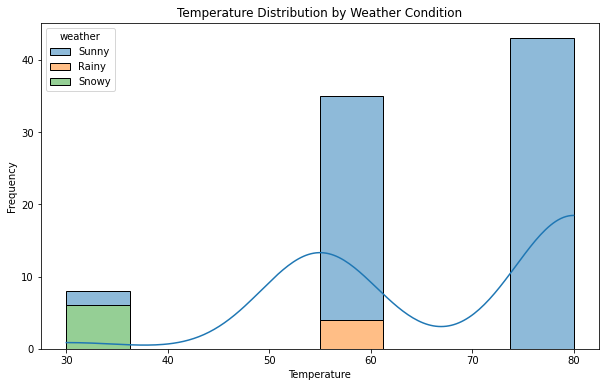

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your data
data = pd.read_csv('coupons.csv')

# Create the histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='temperature', hue='weather', multiple='stack', kde=True)

# Add descriptive labels
plt.title('Temperature Distribution by Weather Condition')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

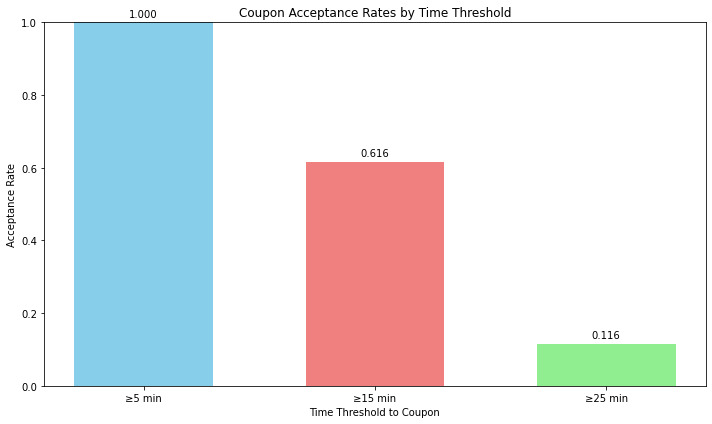

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate acceptance rates for each time threshold
time_columns = ['toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min']
# Convert "Yes"/"No" to 1/0 before calculating mean
acceptance_rates = [(data[col] == 'Yes').mean() for col in time_columns]

# Set up the bar positions
x = np.arange(len(time_columns))
width = 0.6

# Create the grouped bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(x, acceptance_rates, width, color=['skyblue', 'lightcoral', 'lightgreen'])

# Customize the plot
plt.xlabel('Time Threshold to Coupon')
plt.ylabel('Acceptance Rate')
plt.title('Coupon Acceptance Rates by Time Threshold')
plt.xticks(x, ['≥5 min', '≥15 min', '≥25 min'])
plt.ylim(0, 1)

# Add value labels on bars
for bar, rate in zip(bars, acceptance_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{rate:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

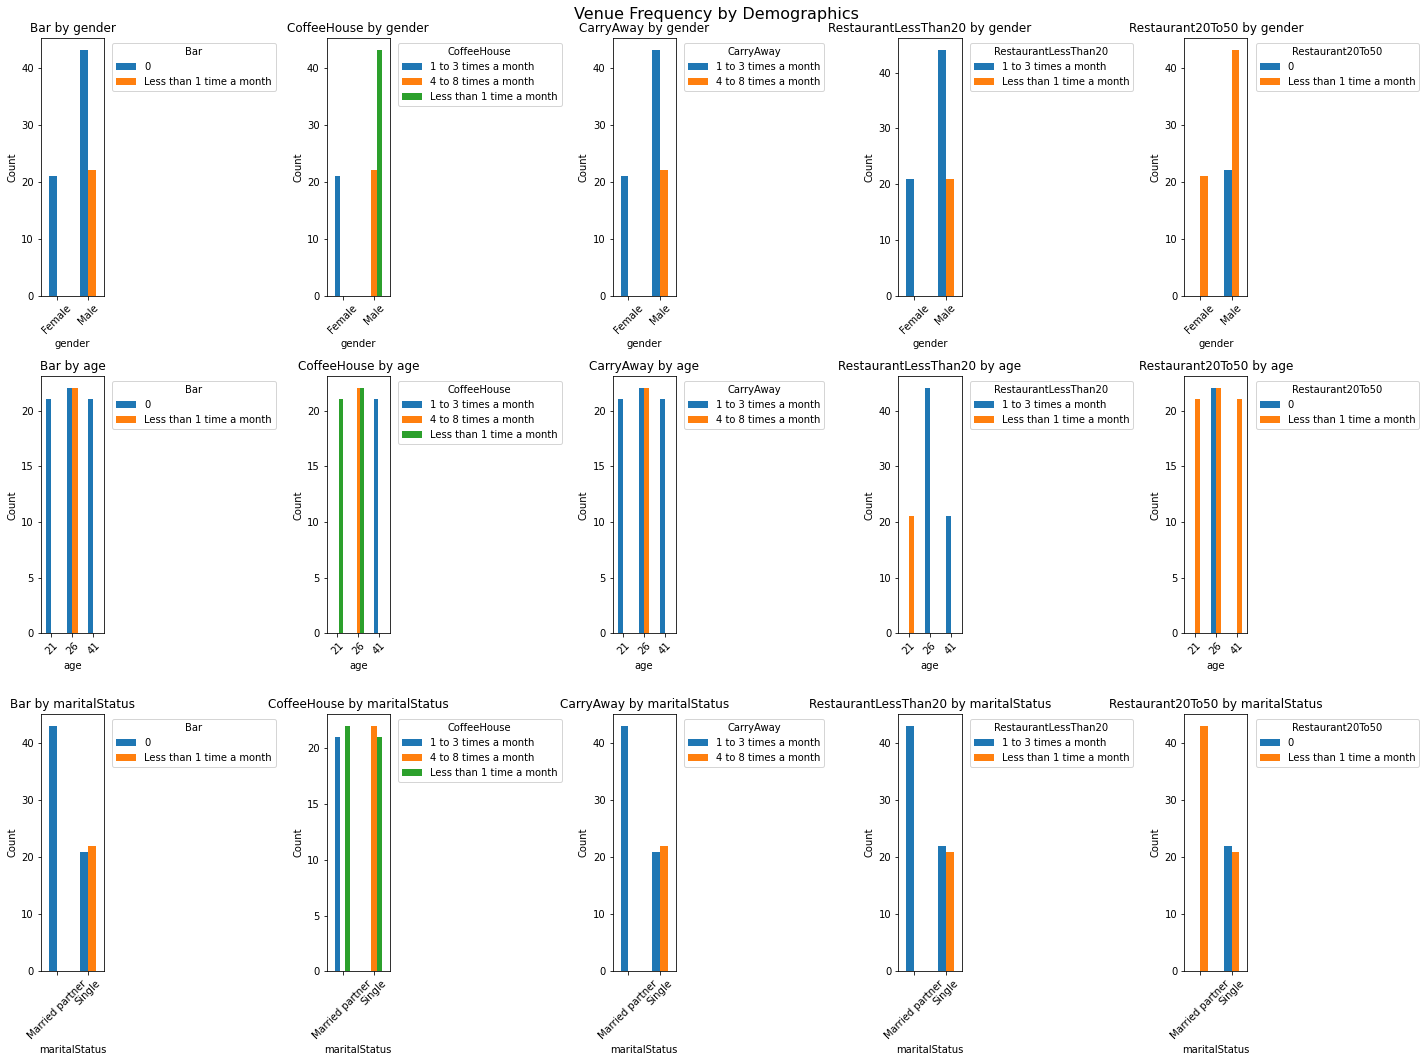

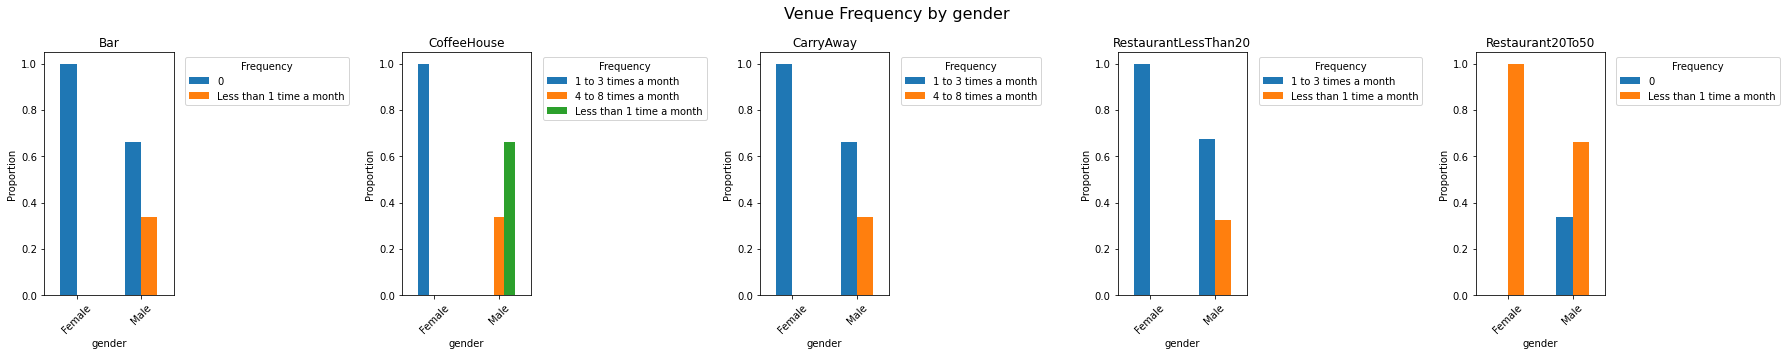

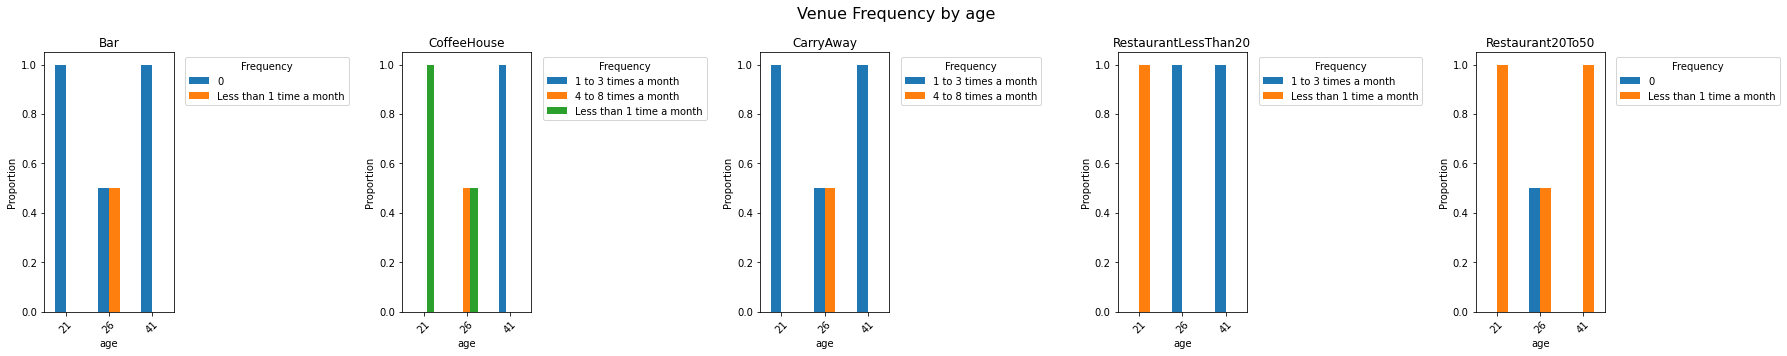

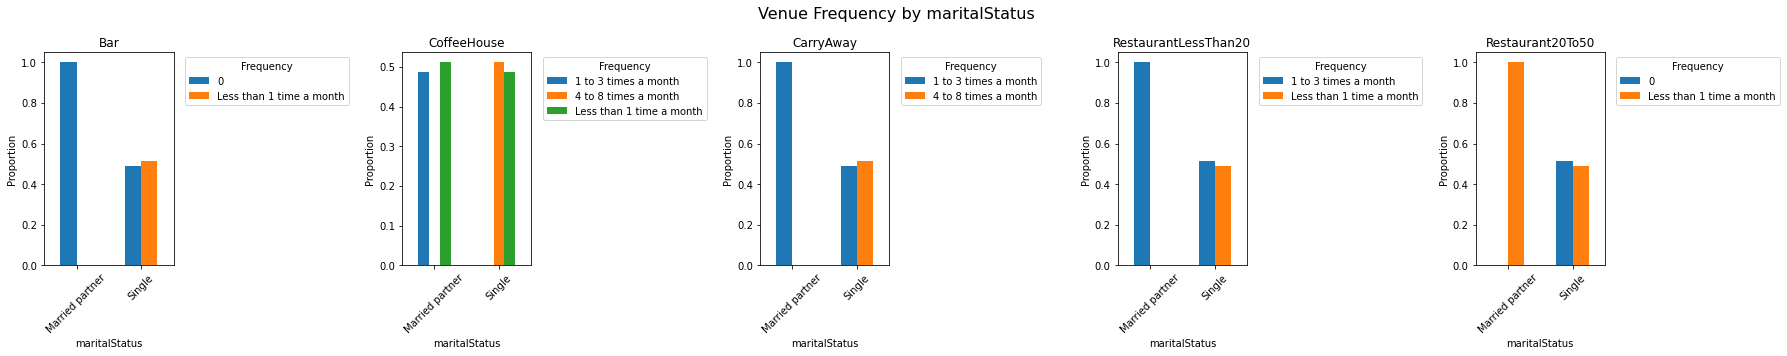

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your data
data = pd.read_csv('coupons.csv')

# Define the venue columns
venue_columns = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']
demographic_columns = ['gender', 'age', 'maritalStatus']

# Create subplots for each demographic variable
fig, axes = plt.subplots(3, 5, figsize=(20, 15))
fig.suptitle('Venue Frequency by Demographics', fontsize=16)

# Loop through each demographic variable
for i, demo_col in enumerate(demographic_columns):
    # Loop through each venue column
    for j, venue_col in enumerate(venue_columns):
        # Create crosstab to get counts
        crosstab = pd.crosstab(data[demo_col], data[venue_col])
        
        # Create bar plot
        crosstab.plot(kind='bar', ax=axes[i, j], rot=45)
        axes[i, j].set_title(f'{venue_col} by {demo_col}')
        axes[i, j].set_xlabel(demo_col)
        axes[i, j].set_ylabel('Count')
        axes[i, j].legend(title=venue_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Alternative: Create separate plots for better readability
for demo_col in demographic_columns:
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f'Venue Frequency by {demo_col}', fontsize=16)
    
    for j, venue_col in enumerate(venue_columns):
        # Calculate proportions instead of raw counts for better comparison
        crosstab = pd.crosstab(data[demo_col], data[venue_col], normalize='index')
        
        crosstab.plot(kind='bar', ax=axes[j], rot=45)
        axes[j].set_title(f'{venue_col}')
        axes[j].set_xlabel(demo_col)
        axes[j].set_ylabel('Proportion')
        axes[j].legend(title='Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()